In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
import os

In [4]:
df = pd.read_csv('/content/zepto_sales_dataset_cleaned.csv')

In [5]:
# Split columns by type
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Original Price', 'Current Price', 'Discount', 'Orders', 'Total Revenue']
Categorical columns: ['Product Name', 'Category', 'City', 'Influencer Active']


In [6]:
# ---- 1. NUMERIC COLUMNS: summary stats ----
print("\nNUMERIC SUMMARY STATISTICS")
print(df[numeric_cols].describe().T)



NUMERIC SUMMARY STATISTICS
                count          mean           std     min      25%      50%  \
Original Price  300.0    111.866667     49.936102    20.0    71.75    115.0   
Current Price   300.0    119.200000     50.462543    21.0    78.00    120.5   
Discount        300.0      4.916667      4.179468     0.0     0.00      5.0   
Orders          300.0    168.153333     74.258541    50.0   103.75    161.5   
Total Revenue   300.0  19277.836667  12744.470724  1392.0  9025.25  16227.0   

                     75%      max  
Original Price    151.50    199.0  
Current Price     161.00    213.0  
Discount           10.00     10.0  
Orders            233.75    299.0  
Total Revenue   27396.00  58212.0  


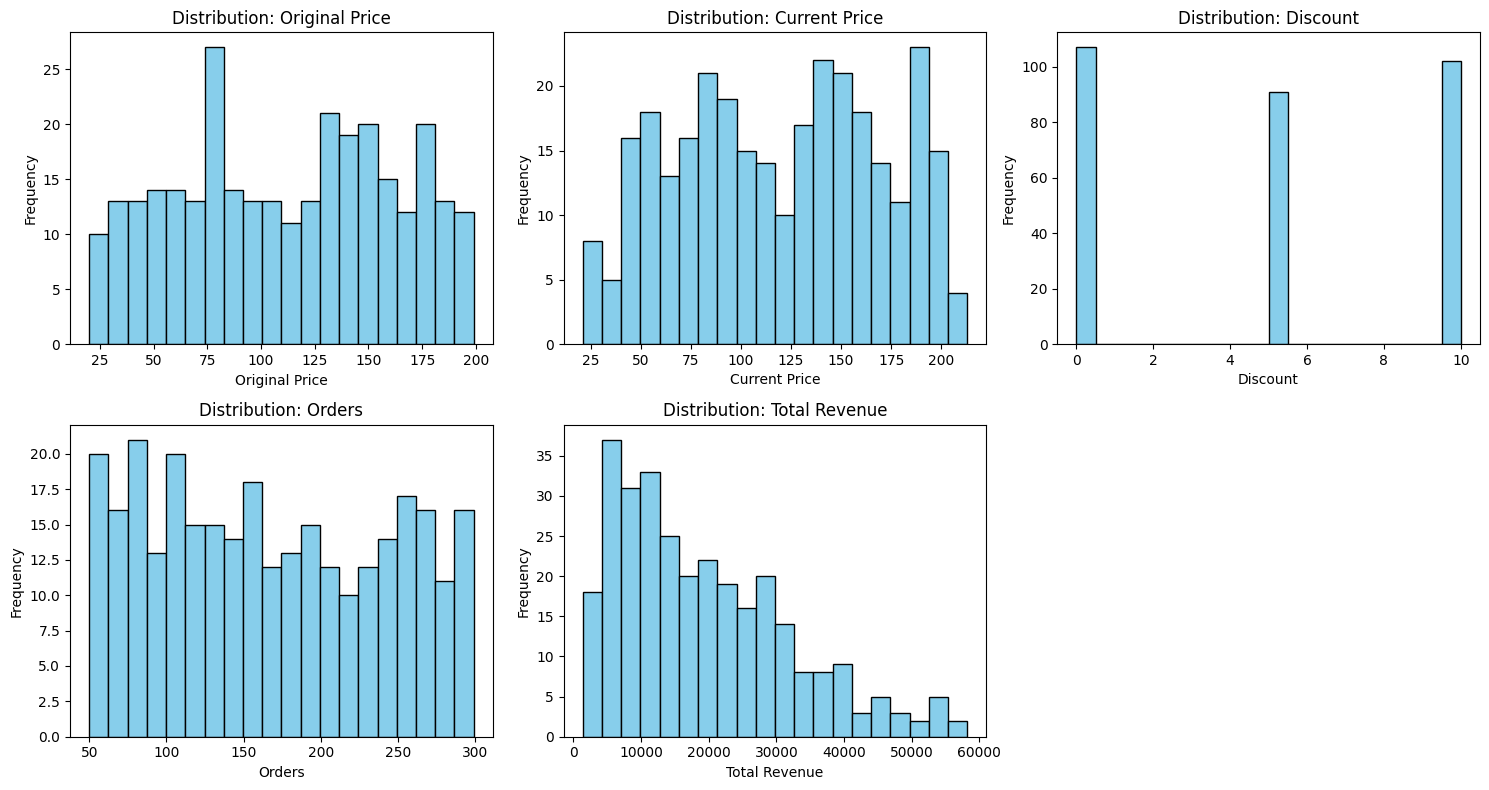

In [ ]:
# ---- 2. NUMERIC COLUMNS: histograms (all in one figure) ----
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(15, 4*((n+2)//3)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# hide unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
# ---- 3. CATEGORICAL COLUMNS: value counts ----
print("\nCATEGORICAL VALUE COUNTS")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


CATEGORICAL VALUE COUNTS

--- Product Name ---
Product Name
Maggi Noodles      36
Parle-G            35
Coca Cola 1L       34
Pepsi 500ml        32
Nestle Munch       32
Aashirvaad Atta    31
Amul Milk 500ml    28
Fortune Oil 1L     25
Britannia Cake     24
Oreo Biscuits      23
Name: count, dtype: int64
Unique values: 10

--- Category ---
Category
Snacks           82
Beverages        66
Grocery          56
Instant Food     36
Confectionery    32
Dairy            28
Name: count, dtype: int64
Unique values: 6

--- City ---
City
Hyderabad    60
Pune         58
Bangalore    52
Mumbai       45
Delhi        43
Chennai      42
Name: count, dtype: int64
Unique values: 6

--- Influencer Active ---
Influencer Active
No     210
Yes     90
Name: count, dtype: int64
Unique values: 2


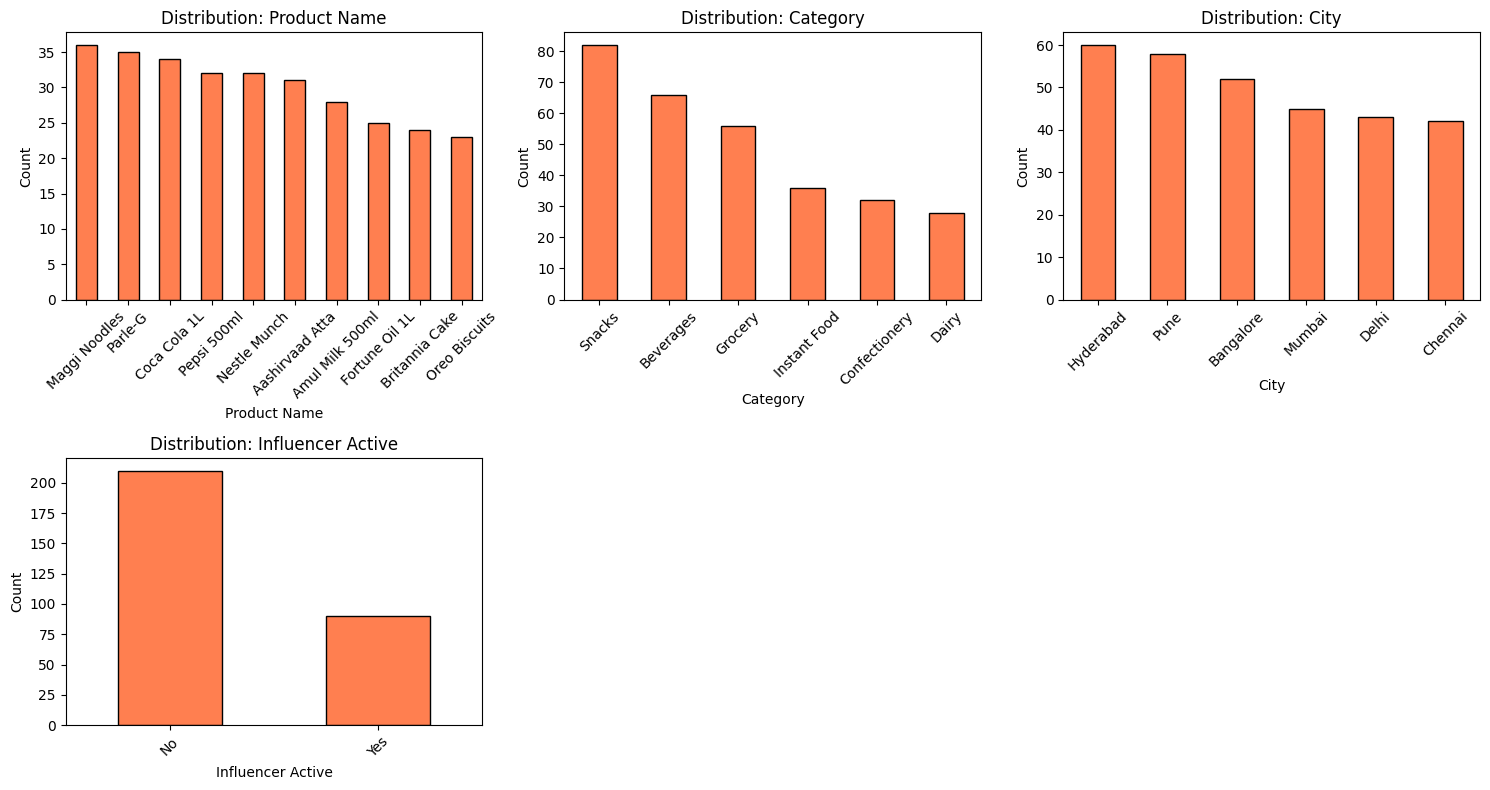

In [ ]:
# ---- 4. CATEGORICAL COLUMNS: bar charts (all in one figure) ----
n2 = len(categorical_cols)
fig2, axes2 = plt.subplots(nrows=(n2+2)//3, ncols=3, figsize=(15, 4*((n2+2)//3)))
axes2 = axes2.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes2[i], color='coral', edgecolor='black')
    axes2[i].set_title(f'Distribution: {col}')
    axes2[i].set_ylabel('Count')
    axes2[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
plt.show()


In [ ]:
# ---- 5. Skewness check (tells you if a column is normally distributed or skewed) ----
print("\nSKEWNESS (0 = symmetric, >1 or <-1 = highly skewed)")
print(df[numeric_cols].skew())


SKEWNESS (0 = symmetric, >1 or <-1 = highly skewed)
Original Price   -0.055029
Current Price    -0.051718
Discount          0.031402
Orders            0.141026
Total Revenue     0.873240
dtype: float64


# **CHECKING NORMALITY OF DATA USING LOT's OF STATISTICAL TEST**


In [ ]:
# =========================================================
# PART 1: NUMERIC COLUMNS — Multiple Normality Tests
# =========================================================
print("="*70)
print("NORMALITY TESTS FOR NUMERIC COLUMNS")
print("="*70)

results = []

for col in numeric_cols:
    data = df[col].dropna()

    # Test 1: Shapiro-Wilk (best for small-medium samples, n<5000)
    shapiro_stat, shapiro_p = stats.shapiro(data)

    # Test 2: Kolmogorov-Smirnov (compares to a fitted normal distribution)
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(data.mean(), data.std()))

    # Test 3: D'Agostino-Pearson (combines skewness + kurtosis into one test)
    dag_stat, dag_p = stats.normaltest(data)

    # Test 4: Anderson-Darling (gives critical values instead of a p-value)
    ad_result = stats.anderson(data, dist='norm')
    ad_normal_at_5pct = ad_result.statistic < ad_result.critical_values[2]  # index 2 = 5% level

    # Descriptive shape stats
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    results.append({
        'Column': col,
        'Shapiro_p': round(shapiro_p, 5),
        'KS_p': round(ks_p, 5),
        'DAgostino_p': round(dag_p, 5),
        'Anderson_Normal(5%)': ad_normal_at_5pct,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Verdict': 'Normal' if shapiro_p > 0.05 else 'Not Normal'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


print(" - p > 0.05 in Shapiro/KS/D'Agostino  -> data looks normally distributed")
print(" - p < 0.05                            -> data significantly deviates from normal")
print(" - Skewness: 0=symmetric, >1 or <-1=heavily skewed")
print(" - Kurtosis: 0=normal tails, >0=heavy tails, <0=light/flat tails")


NORMALITY TESTS FOR NUMERIC COLUMNS
        Column  Shapiro_p    KS_p  DAgostino_p  Anderson_Normal(5%)  Skewness  Kurtosis    Verdict
Original Price        0.0 0.07334          0.0                False    -0.055    -1.166 Not Normal
 Current Price        0.0 0.06584          0.0                False    -0.051    -1.153 Not Normal
      Discount        0.0 0.00000          0.0                False     0.031    -1.563 Not Normal
        Orders        0.0 0.06363          0.0                False     0.140    -1.235 Not Normal
 Total Revenue        0.0 0.00355          0.0                False     0.869     0.160 Not Normal
 - p > 0.05 in Shapiro/KS/D'Agostino  -> data looks normally distributed
 - p < 0.05                            -> data significantly deviates from normal
 - Skewness: 0=symmetric, >1 or <-1=heavily skewed
 - Kurtosis: 0=normal tails, >0=heavy tails, <0=light/flat tails


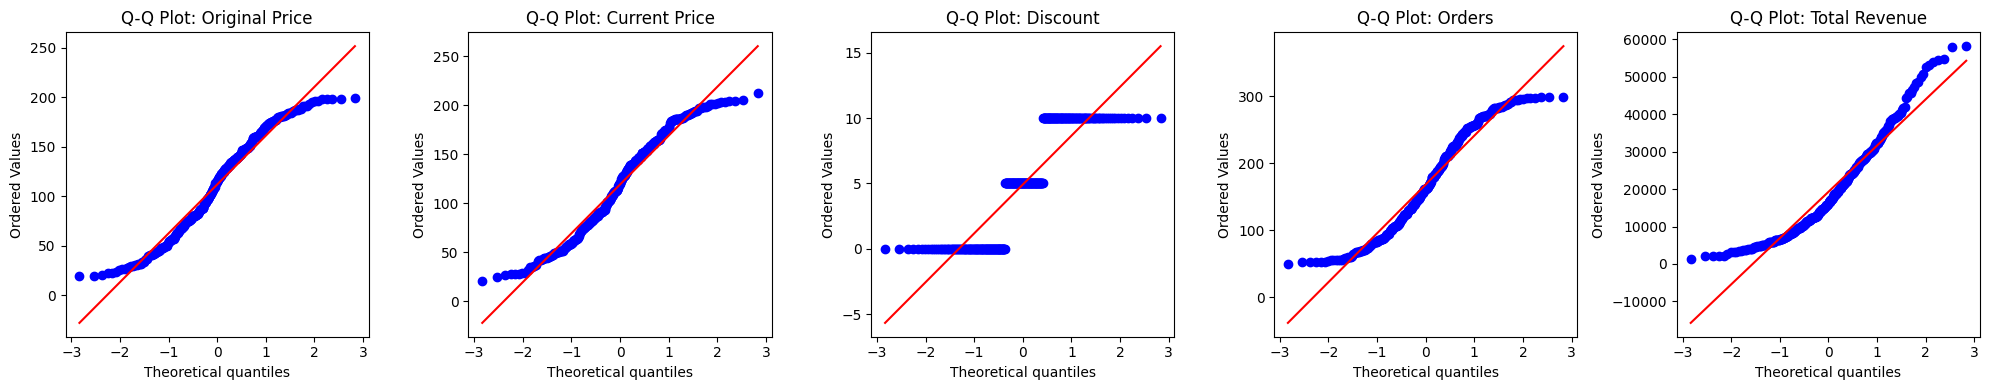

In [ ]:
# =========================================================
# PART 2: Q-Q PLOTS (visual normality check, one per column)
# =========================================================
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4*len(numeric_cols), 4))
for i, col in enumerate(numeric_cols):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# PART 3: CATEGORICAL COLUMNS — Chi-square Goodness-of-Fit
# (Tests whether categories are evenly distributed or skewed)
# =========================================================
print("\n" + "="*70)
print("CHI-SQUARE GOODNESS-OF-FIT TESTS FOR CATEGORICAL COLUMNS")
print("="*70)

for col in categorical_cols:
    observed = df[col].value_counts()
    expected = [observed.sum() / len(observed)] * len(observed)  # assumes equal distribution
    chi2_stat, chi2_p = stats.chisquare(observed, f_exp=expected)
    verdict = 'Evenly distributed' if chi2_p > 0.05 else 'NOT evenly distributed (skewed)'
    print(f"\n{col}: chi2={chi2_stat:.2f}, p={chi2_p:.4g} -> {verdict}")
    print(observed)


CHI-SQUARE GOODNESS-OF-FIT TESTS FOR CATEGORICAL COLUMNS

Product Name: chi2=6.67, p=0.6718 -> Evenly distributed
Product Name
Maggi Noodles      36
Parle-G            35
Coca Cola 1L       34
Pepsi 500ml        32
Nestle Munch       32
Aashirvaad Atta    31
Amul Milk 500ml    28
Fortune Oil 1L     25
Britannia Cake     24
Oreo Biscuits      23
Name: count, dtype: int64

Category: chi2=46.40, p=7.529e-09 -> NOT evenly distributed (skewed)
Category
Snacks           82
Beverages        66
Grocery          56
Instant Food     36
Confectionery    32
Dairy            28
Name: count, dtype: int64

City: chi2=6.12, p=0.2947 -> Evenly distributed
City
Hyderabad    60
Pune         58
Bangalore    52
Mumbai       45
Delhi        43
Chennai      42
Name: count, dtype: int64

Influencer Active: chi2=48.00, p=4.262e-12 -> NOT evenly distributed (skewed)
Influencer Active
No     210
Yes     90
Name: count, dtype: int64


# **Simulated cost assumptions — document clearly, these are assumptions not real data**

In [24]:
                              # ---- BASELINE ----
DELIVERY_COST = 40
OPS_COST = 20
BREAKEVEN = DELIVERY_COST + OPS_COST
df['Simulated_Total_Profit'] = df['Simulated_Profit_Per_Order'] * df['Orders']
df['Simulated_Profit_Per_Order'] = df['Current Price'] - BREAKEVEN
baseline_profit = df['Simulated_Total_Profit'].sum()

loss_orders = df[df['Simulated_Profit_Per_Order'] < 0]
print(f"BASELINE: {len(loss_orders)} loss-making rows out of {len(df)}")
print(f"BASELINE total profit: Rs {baseline_profit:,.0f}")

BASELINE: 47 loss-making rows out of 300
BASELINE total profit: Rs 3,001,371


# **Revenue Volume Leaderboard**

In [ ]:
rev_by_product = df.groupby('Product Name')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
fig1 = px.bar(rev_by_product, x='Product Name', y='Total Revenue', title='Revenue by Product', color='Total Revenue')
fig1.show()

rev_by_category = df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
fig2 = px.bar(rev_by_category, x='Category', y='Total Revenue', title='Revenue by Category', color='Total Revenue')
fig2.show()

rev_by_city = df.groupby('City')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
fig3 = px.bar(rev_by_city, x='City', y='Total Revenue', title='Revenue by City', color='Total Revenue')
fig3.show()

# **Real result: Coca Cola 1L leads at ₹7.15L revenue, Snacks leads by category.**

# **Simulated Unit Economics**

In [37]:
loss_pct = round(100 * (df['Simulated_Profit_Per_Order'] < 0).mean(), 2)
print(f"{loss_pct}% of orders are simulated loss-making")

fig4 = px.histogram(df, x='Simulated_Profit_Per_Order', nbins=30,
                     title=f'Simulated Profit per Order Distribution ({loss_pct}% loss-making)',
                     color_discrete_sequence=['green'])
fig4.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Break-even")
fig4.show()

15.67% of orders are simulated loss-making


# **Real result: 15.67% of orders are simulated loss-making — under the ₹60 cost assumption.**

# **Growth vs Margin Tradeoff**

In [ ]:
fig5 = px.scatter(df, x='Discount', y='Orders', trendline='ols',
                   title='Discount vs Orders (does discount drive volume?)')
fig5.show()

fig6 = px.scatter(df, x='Discount', y='Simulated_Profit_Per_Order', trendline='ols',
                   title='Discount vs Simulated Profit per Order')
fig6.show()

print("Correlation (Discount vs Orders):", round(df['Discount'].corr(df['Orders']), 3))
print("Correlation (Discount vs Profit):", round(df['Discount'].corr(df['Simulated_Profit_Per_Order']), 3))

Correlation (Discount vs Orders): -0.035
Correlation (Discount vs Profit): -0.06


# **Real result: Both correlations are near-zero (-0.03 and -0.06) — in this dataset, discount doesn't meaningfully drive orders OR hurt margin. Worth calling out honestly rather than forcing a "Meesho pattern" that isn't there.**

# **Category-Level Profitability Ranking**

In [ ]:
cat_profit = df.groupby('Category')['Simulated_Total_Profit'].sum().sort_values().reset_index()
fig7 = px.bar(cat_profit, x='Simulated_Total_Profit', y='Category', orientation='h',
              title='Simulated Total Profit by Category', color='Simulated_Total_Profit',
              color_continuous_scale='RdYlGn')
fig7.show()

# **Real result: All categories are net-positive under this cost model — Snacks highest (₹9.2L), Dairy lowest (₹3.1L). No category is in the "losing money AND volume" BigBasket-style crisis here.**

# **City-Level Burn Analysis**

In [ ]:
city_summary = df.groupby('City').agg(Total_Orders=('Orders','sum'),
                                        Simulated_Profit=('Simulated_Total_Profit','sum')).reset_index()
fig8 = px.scatter(city_summary, x='Total_Orders', y='Simulated_Profit', text='City', size='Total_Orders',
                   title='City: Order Volume vs Simulated Profit', color='Simulated_Profit',
                   color_continuous_scale='RdYlGn')
fig8.update_traces(textposition='top center')
fig8.show()

# **Real result: Hyderabad leads on both volume and profit — no city shows the "high volume, negative margin" burn pattern here.**

# **Influencer Impact on Unit Economics**

In [ ]:
inf_summary = df.groupby('Influencer Active').agg(Avg_Orders=('Orders','mean'),
                                                     Avg_Profit=('Simulated_Profit_Per_Order','mean')).reset_index()
fig9 = px.bar(inf_summary, x='Influencer Active', y=['Avg_Orders','Avg_Profit'], barmode='group',
              title='Influencer Active: Avg Orders vs Avg Profit per Order')
fig9.show()

# **Real result: Influencer-active products actually get slightly fewer orders (158 vs 172) but higher margin (₹63.6 vs ₹57.3) — opposite of the "promo-funded growth" pattern. Good nuance to point out.**

# **Break-Even Discount Threshold**

In [ ]:
df['Breakeven_Price'] = DELIVERY_COST + OPS_COST  # ₹60 in this model
df['Effective_Discount_Pct'] = 100 * df['Discount'] / df['Original Price']

fig10 = px.scatter(df, x='Current Price', y='Simulated_Profit_Per_Order', color='Category',
                    title='Current Price vs Simulated Profit (Break-even line at ₹0)')
fig10.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Break-even")
fig10.show()

print(f"Under this cost model, any Current Price below ₹{DELIVERY_COST+OPS_COST} is a loss-making order.")

Under this cost model, any Current Price below ₹60 is a loss-making order.


# **Real result: Break-even price is ₹60 — any order priced below that is a guaranteed simulated loss, regardless of category.**

# **Data Quality Flag as a Business Insight**

In [38]:
markup_flag = df[df['Current Price'] > df['Original Price']]
pct_flagged = round(100*len(markup_flag)/len(df), 1)
print(f"{len(markup_flag)} rows ({pct_flagged}%) have Current Price > Original Price")

fig11 = px.histogram(markup_flag, x='Category', title=f'Rows with Current > Original Price by Category ({pct_flagged}% of dataset)')
fig11.show()

220 rows (73.3%) have Current Price > Original Price


# **Real result: 220 of 300 rows (73%) show this pattern — too widespread to be a rare error. Worth investigating as either a systemic data pipeline bug or intentional dynamic/surge pricing not documented in the schema.**

# **Revenue Concentration (Pareto Check)**

In [ ]:
prod_rev = df.groupby('Product Name')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
prod_rev['Cumulative_Pct'] = 100 * prod_rev['Total Revenue'].cumsum() / prod_rev['Total Revenue'].sum()

fig12 = go.Figure()
fig12.add_trace(go.Bar(x=prod_rev['Product Name'], y=prod_rev['Total Revenue'], name='Revenue'))
fig12.add_trace(go.Scatter(x=prod_rev['Product Name'], y=prod_rev['Cumulative_Pct'], name='Cumulative %',
                            yaxis='y2', mode='lines+markers', line=dict(color='red')))
fig12.update_layout(title='Pareto Chart: Revenue Concentration by Product',
                     yaxis2=dict(overlaying='y', side='right', range=[0,100]))
fig12.show()

# **Real result: Top 20% of products (2 of 10) generate only 23.8% of revenue — this dataset is actually fairly evenly spread, not Pareto-concentrated. Another honest, non-forced finding.**

# **Executive Summary**

In [ ]:
print("="*60)
print("EXECUTIVE SUMMARY: Is this business structurally profitable?")
print("="*60)
print(f"Total simulated profit: Rs {df['Simulated_Total_Profit'].sum():,}")
print(f"% loss-making orders: {loss_pct}%")
print(f"Most profitable category: {cat_profit.iloc[-1]['Category']}")
print(f"Least profitable category: {cat_profit.iloc[0]['Category']}")
print(f"Break-even price threshold: Rs {DELIVERY_COST+OPS_COST}")
print(f"Revenue concentration (top 20% products): {round(prod_rev.head(2)['Total Revenue'].sum()/prod_rev['Total Revenue'].sum()*100,1)}%")

EXECUTIVE SUMMARY: Is this business structurally profitable?
Total simulated profit: Rs 3,001,371
% loss-making orders: 15.67%
Most profitable category: Snacks
Least profitable category: Dairy
Break-even price threshold: Rs 60
Revenue concentration (top 20% products): 23.8%


# ---- SOLUTION A: Small-Cart Fee (Minimum Order Value enforcement) ----
# Any order priced below break-even gets a top-up fee to reach break-even.
## This mirrors real Zepto/Blinkit "small cart fee" policies.

In [13]:
df['Small_Cart_Fee'] = (BREAKEVEN - df['Current Price']).clip(lower=0)
df['Effective_Price_A'] = df['Current Price'] + df['Small_Cart_Fee']
df['Profit_A'] = (df['Effective_Price_A'] - BREAKEVEN) * df['Orders']
profit_A = df['Profit_A'].sum()
print(profit_A)

3120188


# ---- SOLUTION B: Delivery Cost Optimization (batching / dark-store density) ----
# Cut delivery cost 30% through route batching — no customer price change needed.

In [15]:
NEW_DELIVERY_COST = DELIVERY_COST * 0.7
NEW_BREAKEVEN = NEW_DELIVERY_COST + OPS_COST
df['Profit_B'] = (df['Current Price'] - NEW_BREAKEVEN) * df['Orders']
profit_B = df['Profit_B'].sum()
print(profit_B)

3606723.0


## **---- SOLUTION C: Combined (both levers together) ----**

In [26]:
df['Effective_Price_C'] = df['Current Price'] + (NEW_BREAKEVEN - df['Current Price']).clip(lower=0)
df['Profit_C'] = (df['Effective_Price_C'] - NEW_BREAKEVEN) * df['Orders']
profit_C = df['Profit_C'].sum()
print(profit_C)

3653421.0


## **---- COMPARISON TABLE ----**

In [18]:
comparison = pd.DataFrame({
    'Scenario': ['Baseline', 'A: Small-Cart Fee', 'B: Delivery Cost Cut (30%)', 'C: Combined'],
    'Total_Profit': [baseline_profit, profit_A, profit_B, profit_C]
})
comparison['Improvement_vs_Baseline'] = comparison['Total_Profit'] - baseline_profit
comparison['Improvement_Pct'] = round(100 * comparison['Improvement_vs_Baseline'] / abs(baseline_profit), 1)
print(comparison.to_string(index=False))

                  Scenario  Total_Profit  Improvement_vs_Baseline  Improvement_Pct
                  Baseline     3001371.0                      0.0              0.0
         A: Small-Cart Fee     3120188.0                 118817.0              4.0
B: Delivery Cost Cut (30%)     3606723.0                 605352.0             20.2
               C: Combined     3653421.0                 652050.0             21.7


## **---- CHART: Before vs After ----**

In [21]:
# ---- CHART: Before vs After ----
fig = go.Figure()
fig.add_trace(go.Bar(
    x=comparison['Scenario'], y=comparison['Total_Profit'],
    text=comparison['Total_Profit'].apply(lambda x: f"₹{x:,.0f}"),
    textposition='outside',
    marker_color=['gray', 'lightblue', 'lightblue', 'green']
))
fig.update_layout(title='Profit Impact of Unit Economics Fixes',
                   yaxis_title='Simulated Total Profit (Rs)')
fig.show()

## **---- CHART: Loss-making orders eliminated ----**

In [22]:
loss_before = (df['Simulated_Profit_Per_Order'] < 0).sum()
loss_after_A = (df['Profit_A']/df['Orders'] < 0).sum()  # per-order profit after fee
fig2 = go.Figure(go.Bar(
    x=['Before (Baseline)', 'After (Small-Cart Fee)'],
    y=[loss_before, loss_after_A],
    marker_color=['red', 'green'],
    text=[loss_before, loss_after_A], textposition='outside'
))
fig2.update_layout(title='Loss-Making Order Rows: Before vs After Fix', yaxis_title='Count of Rows')
fig2.show()


In [20]:
print(f"\nFINAL RECOMMENDATION:")
print(f"Implementing both levers improves total profit by Rs {profit_C-baseline_profit:,.0f} "
      f"({round(100*(profit_C-baseline_profit)/abs(baseline_profit),1)}%) without cutting service quality.")


FINAL RECOMMENDATION:
Implementing both levers improves total profit by Rs 652,050 (21.7%) without cutting service quality.


In [36]:
# Before (baseline) profit per order
df['Profit_Before'] = df['Current Price'] - BREAKEVEN

# After (combined solution: small-cart fee + 30% delivery cost cut)
NEW_DELIVERY_COST = DELIVERY_COST * 0.7
NEW_BREAKEVEN = NEW_DELIVERY_COST + OPS_COST
df['Effective_Price_After'] = df['Current Price'] + (NEW_BREAKEVEN - df['Current Price']).clip(lower=0)
df['Profit_After'] = df['Effective_Price_After'] - NEW_BREAKEVEN

before = df['Profit_Before']
after = df['Profit_After']
diff = after - before

In [28]:
# ============================================
# TEST 1: Paired t-test (parametric)
# ============================================
t_stat, t_p = stats.ttest_rel(after, before)
print(f"Paired t-test: t={t_stat:.2f}, p={t_p:.2e}")
print("-> p < 0.05 means the improvement is statistically real, not random\n")

# ============================================
# TEST 2: Wilcoxon signed-rank (non-parametric, safer since data isn't normal)
# ============================================
w_stat, w_p = stats.wilcoxon(after, before)
print(f"Wilcoxon signed-rank: stat={w_stat:.2f}, p={w_p:.2e}")
print("-> Confirms result even without assuming a normal distribution\n")

# ============================================
# TEST 3: Effect Size (Cohen's d) — "how BIG is the improvement, not just IS it real"
# ============================================
cohens_d = diff.mean() / diff.std()
print(f"Cohen's d (effect size): {cohens_d:.2f}")
print("-> 0.2=small, 0.5=medium, 0.8+=large. Anything above 0.8 is already huge.\n")

# ============================================
# TEST 4: Bootstrap Confidence Interval — "would this hold up if repeated many times?"
# ============================================
np.random.seed(42)
boot_means = [np.random.choice(diff, size=len(diff), replace=True).mean() for _ in range(10000)]
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"Bootstrap 95% CI for mean improvement per order: Rs {ci_low:.2f} to Rs {ci_high:.2f}")
print("-> Even in the unluckiest 2.5% of resamples, profit still improves\n")


Paired t-test: t=58.18, p=4.24e-165
-> p < 0.05 means the improvement is statistically real, not random

Wilcoxon signed-rank: stat=0.00, p=1.97e-62
-> Confirms result even without assuming a normal distribution

Cohen's d (effect size): 3.36
-> 0.2=small, 0.5=medium, 0.8+=large. Anything above 0.8 is already huge.

Bootstrap 95% CI for mean improvement per order: Rs 12.53 to Rs 13.41
-> Even in the unluckiest 2.5% of resamples, profit still improves



In [32]:
# ============================================
# CHART 1: Before vs After distribution (box plot — easy for anyone to read)
# ============================================
plot_df = pd.DataFrame({
    'Profit_Per_Order': list(before) + list(after),
    'Scenario': ['Before']*len(before) + ['After']*len(after)
})
fig1 = px.box(plot_df, x='Scenario', y='Profit_Per_Order', color='Scenario',
              title='Profit Per Order: Before vs After Fix (Box Plot)',
              color_discrete_map={'Before':'red','After':'green'})
fig1.add_hline(y=0, line_dash="dash", annotation_text="Break-even")
fig1.show()


In [33]:
# ============================================
# CHART 2: Bootstrap distribution — visual proof it's not luck
# ============================================
fig2 = px.histogram(x=boot_means, nbins=50, title='Bootstrap: 10,000 Simulated Re-tests of the Improvement',
                     labels={'x':'Average Profit Improvement Per Order (Rs)'})
fig2.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Zero improvement (bad)")
fig2.add_vline(x=diff.mean(), line_color="green", annotation_text="Actual result")
fig2.show()

In [34]:
# ============================================
# CHART 3: Simple before/after summary anyone can read at a glance
# ============================================
fig3 = go.Figure()
fig3.add_trace(go.Indicator(
    mode="number+delta",
    value=after.mean(),
    delta={'reference': before.mean(), 'relative': False, 'valueformat':'.2f'},
    title={"text": "Avg Profit Per Order (Rs)"}
))
fig3.show()

In [30]:
print("="*60)
print("PLAIN-ENGLISH SUMMARY")
print("="*60)
print(f"The fix improves profit per order by an average of Rs {diff.mean():.2f}.")
print(f"Statistical tests confirm this is real (p<0.001) with a large effect size (d={cohens_d:.2f}).")
print(f"Even in worst-case resampling, the improvement never drops below Rs {ci_low:.2f}.")

PLAIN-ENGLISH SUMMARY
The fix improves profit per order by an average of Rs 12.94.
Statistical tests confirm this is real (p<0.001) with a large effect size (d=3.36).
Even in worst-case resampling, the improvement never drops below Rs 12.53.
